In [1]:
import sklearn
sklearn.__version__

'1.7.2'

# 1. Linear Regression

## 공부 시간에 따른 시험 점수


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset = pd.read_csv('LinearRegressionData.csv')

In [5]:
dataset.head()

,hour,score
0,0.5,10
1,1.2,8
2,1.8,14
3,2.4,26
4,2.6,22


In [7]:
X = dataset.iloc[:, :-1].values # 처음부터 마지막 컬럼 직전까지의 데이터 (독립 변수)
y = dataset.iloc[:,-1].values # 마지막 컬럼 데이터 (종속 변수 - 결과)

In [8]:
X, y

(array([[ 0.5],
        [ 1.2],
        [ 1.8],
        [ 2.4],
        [ 2.6],
        [ 3.2],
        [ 3.9],
        [ 4.4],
        [ 4.5],
        [ 5. ],
        [ 5.3],
        [ 5.8],
        [ 6. ],
        [ 6.1],
        [ 6.2],
        [ 6.9],
        [ 7.2],
        [ 8.4],
        [ 8.6],
        [10. ]]),
 array([ 10,   8,  14,  26,  22,  30,  42,  48,  38,  58,  60,  72,  62,
         68,  72,  58,  76,  86,  90, 100]))

In [10]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression() # 객체 생성
reg.fit(X, y) # 학습 (모델 생성)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = reg.predict(X) # X에 대한 예측 값
y_pred

array([  5.00336377,  12.31395163,  18.58016979,  24.84638795,
        26.93512734,  33.20134551,  40.51193337,  45.73378184,
        46.77815153,  52.        ,  55.13310908,  60.35495755,
        62.44369694,  63.48806663,  64.53243633,  71.84302419,
        74.97613327,  87.5085696 ,  89.59730899, 104.2184847 ])

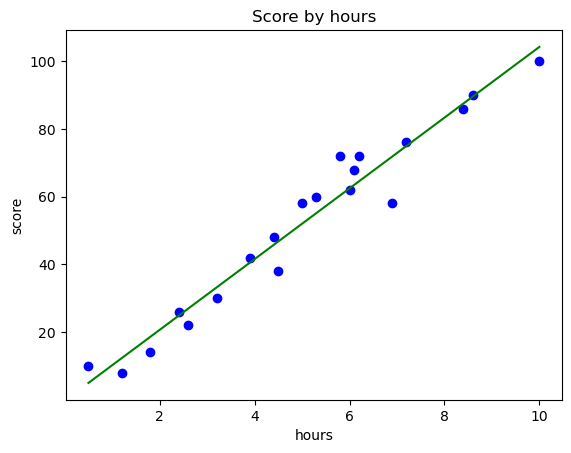

In [12]:
plt.scatter(X, y, color='b') # 산점도
plt.plot(X, y_pred, color='g') # 선 그래프
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [14]:
print('9시간 공부했을 때 예상 점수: ', reg.predict([[9], [8], [7]]))

9시간 공부했을 때 예상 점수:  [93.77478776 83.33109082 72.88739388]


In [15]:
reg.coef_ # 기울기 (m)

array([10.44369694])

In [16]:
reg.intercept_ # y 절편 (b)

np.float64(-0.21848470286721522)

y = mx + b -> y = 10.4436x - 0.2184

## 데이터 세트 분리

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('LinearRegressionData.csv')

In [3]:
dataset

,hour,score
0,0.5,10
1,1.2,8
2,1.8,14
3,2.4,26
4,2.6,22
5,3.2,30
6,3.9,42
7,4.4,48
8,4.5,38
9,5.0,58


In [12]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # 훈련 80 : 테스트 20으로 분리

In [14]:
X, len(X) # 전체 데이터 X, 개수

(array([[ 0.5],
        [ 1.2],
        [ 1.8],
        [ 2.4],
        [ 2.6],
        [ 3.2],
        [ 3.9],
        [ 4.4],
        [ 4.5],
        [ 5. ],
        [ 5.3],
        [ 5.8],
        [ 6. ],
        [ 6.1],
        [ 6.2],
        [ 6.9],
        [ 7.2],
        [ 8.4],
        [ 8.6],
        [10. ]]),
 20)

In [15]:
X_train, len(X_train) # 훈련 세트 X, 개수

(array([[5.3],
        [8.4],
        [3.9],
        [6.1],
        [2.6],
        [1.8],
        [3.2],
        [6.2],
        [5. ],
        [4.4],
        [7.2],
        [5.8],
        [2.4],
        [0.5],
        [6.9],
        [6. ]]),
 16)

In [16]:
X_test, len(X_test) # 테스트 세트 X, 개수

(array([[ 8.6],
        [ 1.2],
        [10. ],
        [ 4.5]]),
 4)

In [17]:
y, len(y) # 전체 데이터 y

(array([ 10,   8,  14,  26,  22,  30,  42,  48,  38,  58,  60,  72,  62,
         68,  72,  58,  76,  86,  90, 100]),
 20)

In [20]:
y_train, len(y_train) # 훈련 세트 y, 개수

(array([60, 86, 42, 68, 22, 14, 30, 72, 58, 48, 76, 72, 26, 10, 58, 62]), 16)

In [21]:
y_test, len(X_test) # 테스트 세트 y, 개수

(array([ 90,   8, 100,  38]), 4)

## 분리된 데이터를 통한 모델링

In [23]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [24]:
reg.fit(X_train, y_train) # 훈련 세트로 학습

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 데이터 시각화(훈련 세트)

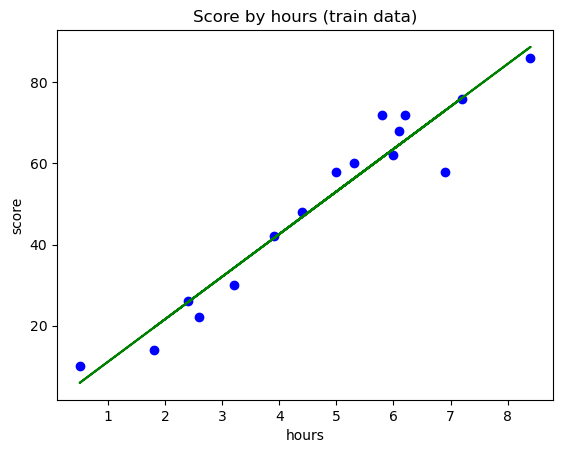

In [26]:
plt.scatter(X_train, y_train, color='b') # 산점도
plt.plot(X_train, reg.predict(X_train), color='g') # 선 그래프
plt.title('Score by hours (train data)')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

## 데이터 시각화 (테스트 세트)

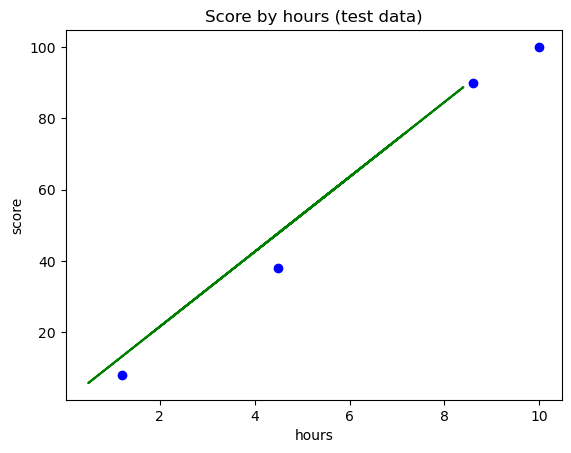

In [27]:
plt.scatter(X_test, y_test, color='b') # 산점도
plt.plot(X_train, reg.predict(X_train), color='g') # 선 그래프
plt.title('Score by hours (test data)')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [31]:
reg.coef_ # 기울기

array([10.49161294])

In [32]:
reg.intercept_ # y절편

np.float64(0.6115562905169796)

## 모델 평가

In [34]:
reg.score(X_test, y_test) # 테스트 세트를 통한 모델 평가

0.9727616474310156

In [37]:
reg.score(X_train, y_train) # 훈련 세트를 통한 모델 평가

0.9356663661221668

# 경사 하강법 (Gradient Descent)

max_iter : 훈련 세트 반복 횟수 (Epoch 횟수)

eta0 : 학습률 (learning rate)

In [64]:
from sklearn.linear_model import SGDRegressor # SGD: Stochastic Gradient Descent 확률적 경사 하강법

# 지수표기법
# 1e-3 : 0.001 (10^-3)
# 1e-4 : 0.0001 (10^-4)
# 1e+3 : 1000 (10^3)
# 1e+4 : 10000 (10^4)

# sr = SGDRegressor(max_iter=500, eta0=1e-4, random_state=0, verbose=1)
sr = SGDRegressor()
sr.fit(X_train, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


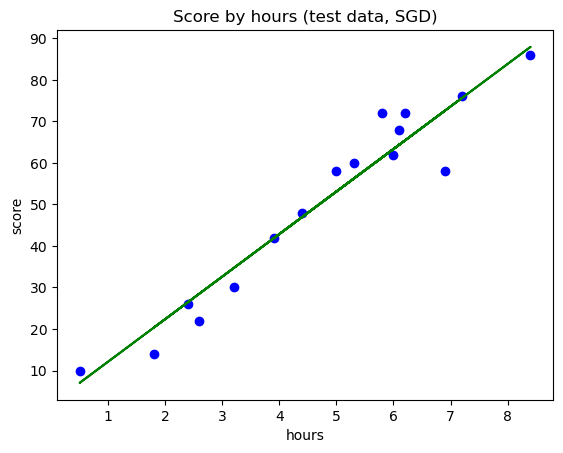

In [65]:
plt.scatter(X_train, y_train, color='b') # 산점도
plt.plot(X_train, sr.predict(X_train), color='g') # 선 그래프
plt.title('Score by hours (test data, SGD)')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [51]:
sr.coef_, sr.intercept_

(array([10.27910813]), array([1.78380236]))

In [52]:
sr.score(X_test, y_test) # 테스트 세트를 통한 모델 평가

0.9719916063560563

In [53]:
sr.score(X_train, y_train) # 훈련 세트를 통한 모델 평가

0.9352292295423332